In [211]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize

import kwant
from scipy import linalg as la
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

# from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function, _hopping_matrix

# from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
# from alter_morph.mean_field import hartree_fock
# from alter_morph.kwant_utilities import Amorphous

from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [212]:
import sys, os

data_name = "data/full_phase_diagram_20_V0.pickle"
data_name = "data/detailed_phase_diagram_20_V0.pickle"

d = pickle.load(open(os.getcwd()[:-8] + data_name, "rb"))

print(d.keys())
print("fillings: ", d["filling"].shape)
print("Js: ", d["J"].shape)
print("params:", d["params"].shape)
print("\t element [0,0]", d["params"][0, 0].keys())
print("data:", d["data"].shape)
print("\t element [0,0]", d["data"][0, 0].keys())
print("\t \t element [0,0] numerical params", d["data"][0, 0]["numerical_param"].keys())
print("\t \t element [0,0] hamilton  params", d["data"][0, 0]["hparam"].keys())

Js = d["J"]
ns = d["filling"]


# introducing the lattice
lattice = pickle.load(open("voronoi_20.pickle", "rb"))
# lead symmetry for conductance simulations
lead_symmetry = np.diag([-1, -1, 1, 1])


def fermi_level(energies, filling):
    if filling == 0:
        return energies[0] - 1
    elif filling == 1:
        return energies[-1] + 1
    return energies[int(filling * len(energies))]

dict_keys(['filling', 'data', 'params', 'J'])
fillings:  (41,)
Js:  (101,)
params: (41, 101)
	 element [0,0] dict_keys(['t1', 't2', 'filling', 'theta_offset', 'J', 'U', 'm', 'n'])
data: (41, 101)
	 element [0,0] dict_keys(['hparam', 'energies', 'numerical_param', 'spin_cond'])
	 	 element [0,0] numerical params dict_keys(['m_values', 'n_values', 'iteration_steps', 'learning_rate', 'tol_mdiff'])
	 	 element [0,0] hamilton  params dict_keys(['t1', 't2', 'filling', 'theta_offset', 'J', 'U', 'm', 'n'])


/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_21500/1487311941.py:54: RuntimeWarning: divide by zero encountered in divide
  array_magnetization.mean(axis=-1)/max_possible_magnetization[:,np.newaxis]*100,


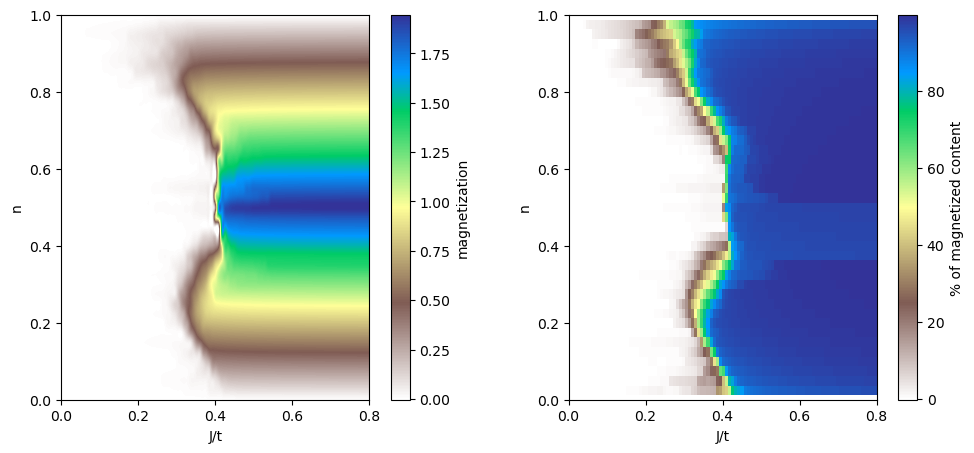

In [ ]:
# the magnetizartion
array_magnetization = np.array(
    [[params["m"] for params in x] for x in d["params"]]
)  # .shape (filling, Js, vertices)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#########################
# absolute magnetization
ax = axs[0]
# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent

im = ax.imshow(
    array_magnetization.mean(axis=-1),
    origin="lower",
    interpolation="spline36",
    extent=extent,
    cmap="terrain_r",
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("magnetization")


#########################
# relative magnetization
ax = axs[1]
# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent

max_possible_magnetization = 2 - np.abs(4 * ns - 2)

im = ax.imshow(
    array_magnetization.mean(axis=-1) / max_possible_magnetization[:, np.newaxis] * 100,
    origin="lower",
    interpolation="none",
    extent=extent,
    cmap="terrain_r",
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("% of magnetized content")

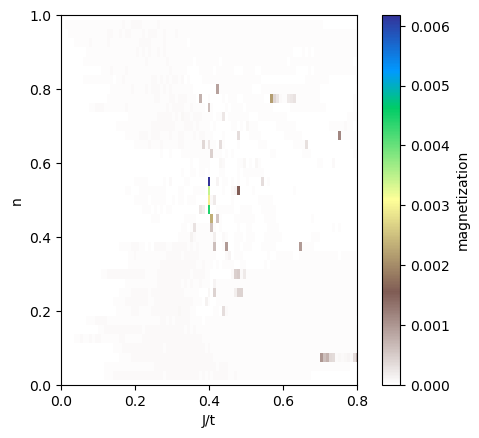

In [ ]:
# check convergence

iterations = np.array(
    [
        [params["numerical_param"]["m_values"].shape[0] for params in x]
        for x in d["data"]
    ]
)  # .shape (filling, Js, vertices)
diffs = np.array(
    [
        [
            params["numerical_param"]["m_values"][-2]
            - params["numerical_param"]["m_values"][-1]
            for params in x
        ]
        for x in d["data"]
    ]
)  # .shape (filling, Js, vertices)
diffs = np.abs(diffs).mean(axis=-1)

fig, ax = plt.subplots(1, 1)

# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent

im = ax.imshow(
    diffs, origin="lower", interpolation="none", extent=extent, cmap="terrain_r"
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("magnetization")

In [213]:
import scipy.optimize as optimize
import scipy.integrate as integrate


def derivative_FD(energy, temperature):
    return 1 / (4 * temperature) / np.cosh(energy / (2 * temperature)) ** 2


def find_int_points_FD(temperature, n):
    """
    finds the ideal integration points x_i and weights w_i to evaluate the integral
    int_{-infinity}^{infinity} f(x) n_FD'(x,temperature) dx = sum_i f(x_i) * n_FD'(x_i,temperature) * w_i
    ### input ###
    temperature: temperatue in the derivative of the Fermi-Dirac function n_FD'
    n: number of integration points to choose

    ### output ###
    integration points x, weights
    """
    if temperature == 0.0:
        print("n not considered")
        return [0], [1]

    # this is outdated:
    # energies = np.linspace(-10*temperature,10*temperature,500)
    # fs = derivative_FD(energies,temperature)
    # popt,_ = optimize.curve_fit(gaussian,energies,fs,p0=temperature*1.6)
    # perfect fitted gaussian has
    # sigma = 1.6296046 * temperature
    # #########################

    # Get Gauss-Hermite quadrature nodes and weights
    # x, weights = np.polynomial.hermite.hermgauss(n)
    # x = x * sigma * 2**0.5 # Transform nodes to match Gaussian width sigma
    # weights = weights /np.pi**0.5 #Transform weights to match unnormalized Gaussian
    ###########################
    ###########################

    # Get Gauss-Legendre quadrature nodes and weights
    def integral_int_boundary(integration_boundary, temperature, n):
        """integrate the raw FD function and compare them to get good integration boundary"""
        xs = np.linspace(-10 * temperature, 10 * temperature, 500)

        int_exact = integrate.trapezoid(derivative_FD(xs, temperature), xs)
        x, weights = np.polynomial.legendre.leggauss(n)
        int_prox = np.sum(
            derivative_FD(x * integration_boundary, temperature)
            * weights
            * integration_boundary
        )
        return int_exact - int_prox

    res = optimize.root(integral_int_boundary, 4, args=(temperature, n))
    optimal_int_boundary = res.x[0]

    x, weights = np.polynomial.legendre.leggauss(n)
    x = x * optimal_int_boundary  # Transform nodes to match integration region
    weights = (
        weights * optimal_int_boundary
    )  # Transform weights to match integration region

    return x, weights

In [ ]:
# calculate spin conductance at finite energy to make it less bulky
temperature = 0.02
number_int_points = 11
perfect_int_points, weights = find_int_points_FD(temperature, number_int_points)
print(perfect_int_points)

# calculate spin conductance
for data_column in tqdm(d["data"]):
    for data_entry in data_column:

        hamiltonian = alt_hamiltonian(
            lattice,
            data_entry["hparam"]["t1"],
            data_entry["hparam"]["t2"],
            data_entry["hparam"]["J"],
            data_entry["hparam"]["J"],
            data_entry["hparam"]["m"],
            data_entry["hparam"]["n"],
            theta_offset=data_entry["hparam"]["theta_offset"],
        )

        # evaluating the Fermi energy
        fermi_energy = fermi_level(
            data_entry["energies"], data_entry["hparam"]["filling"]
        )

        lead_onsite = np.eye(4) * fermi_energy
        lead_coupling = -np.eye(4)

        contact_lattice, k_lattice, k_system, contact_vertices = (
            crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
        )
        kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
            contact_lattice,
            k_lattice,
            k_system,
            contact_vertices,
            lead_onsite,
            lead_coupling,
            lead_symmetry,
        )

        # evaluate at fermi_energy!
        k_system_f = k_system.finalized()
        g = []
        for energy, weight in zip(perfect_int_points + fermi_energy, weights):
            smatrix = kwant.smatrix(k_system_f, energy=energy)
            g_T = np.array(
                [
                    [smatrix.transmission((1, j), (0, i)) for j in range(2)]
                    for i in range(2)
                ]
            )
            g.append(g_T * weight)
        g = np.sum(g, axis=0)

        data_entry["spin_cond"] = g
pickle.dump(d, open(os.getcwd()[:-8] + data_name, "wb"))

[-0.13715988 -0.12437726 -0.10237643 -0.07278376 -0.03779332  0.
  0.03779332  0.07278376  0.10237643  0.12437726  0.13715988]


100%|██████████| 41/41 [1:14:17<00:00, 108.72s/it]


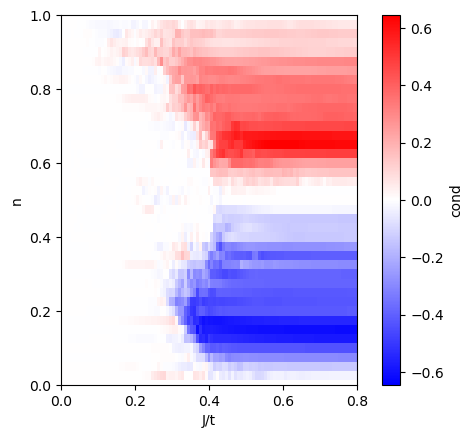

In [ ]:
# the spin_cond
array_spin_cond = np.array(
    [[params["spin_cond"] for params in x] for x in d["data"]]
)  # .shape (filling, Js, 2,2)
array_g0 = array_spin_cond[:, :, 0, 0] + array_spin_cond[:, :, 1, 1]
array_gspin = array_spin_cond[:, :, 0, 0] - array_spin_cond[:, :, 1, 1]

fig, ax = plt.subplots(1, 1)

# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent
vabs = np.abs(array_gspin).max()

im = ax.imshow(
    array_gspin,
    origin="lower",
    interpolation="none",
    extent=extent,
    cmap="bwr",
    vmin=-vabs,
    vmax=vabs,
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("cond")

In [ ]:
g_spin = []
gs = []
fermi_energies = []
spectrals = []
spin_spectrals = []
doss = []
idx_J = 51
# print("n=", ns[idx_n])
print("J=", Js[idx_J])

temperature = 0.02
perfect_int_points, weights = find_int_points_FD(temperature, 11)
print(perfect_int_points)

for idx_n in tqdm(range(d["data"].shape[0])):

    data_entry = d["data"][idx_n, idx_J]

    hamiltonian = alt_hamiltonian(
        lattice,
        data_entry["hparam"]["t1"],
        data_entry["hparam"]["t2"],
        data_entry["hparam"]["J"],
        data_entry["hparam"]["J"],
        data_entry["hparam"]["m"],
        data_entry["hparam"]["n"],
        theta_offset=data_entry["hparam"]["theta_offset"],
    )

    # evaluating the Fermi energy
    fermi_energy = fermi_level(data_entry["energies"], data_entry["hparam"]["filling"])

    lead_onsite = np.eye(4) * fermi_energy
    lead_coupling = -np.eye(4)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        lead_symmetry,
    )

    # evaluate at fermi_energy!
    k_system_f = k_system.finalized()

    g = []
    for energy, weight in zip(perfect_int_points + fermi_energy, weights):
        smatrix = kwant.smatrix(k_system_f, energy=energy)
        g_T = np.array(
            [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
        )
        g.append(g_T * weight)
    g = np.sum(g, axis=0)

    g_spin.append(g[0, 0] - g[1, 1])
    gs.append(g[0, 0] + g[1, 1])
    fermi_energies.append(fermi_energy)

    # spectrals.append(
    #     spectral_function(
    #         lattice,
    #         energies,
    #         states,
    #         fermi_energy,
    #         local_operator=np.array([1,1,1,1]),
    #         eta=1e-1,
    #         n_k=50,
    #     )
    # )
    # spin_spectrals.append(
    #     spectral_function(
    #         lattice,
    #         energies,
    #         states,
    #         fermi_energy,
    #         local_operator=np.array([1, 1, -1, -1]),
    #         eta=1e-1,
    #         n_k=50,
    #     )
    # )
    # #evaluate DOS
    # eta = 1e-2
    # doss.append(np.sum(eta/((energies-fermi_energy)**2+eta**2))/lattice.n_vertices)


# print(g)

n= 0.8500000000000001
[-0.13715988 -0.12437726 -0.10237643 -0.07278376 -0.03779332  0.
  0.03779332  0.07278376  0.10237643  0.12437726  0.13715988]


100%|██████████| 41/41 [00:43<00:00,  1.06s/it]


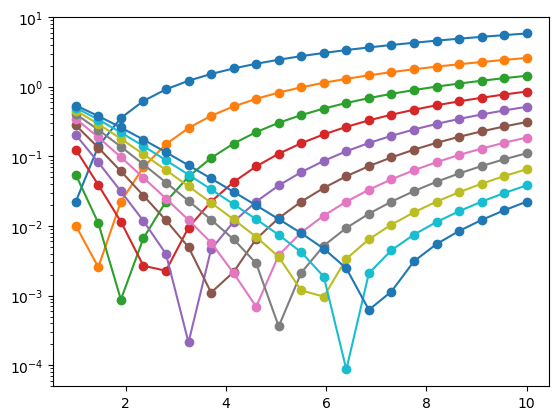

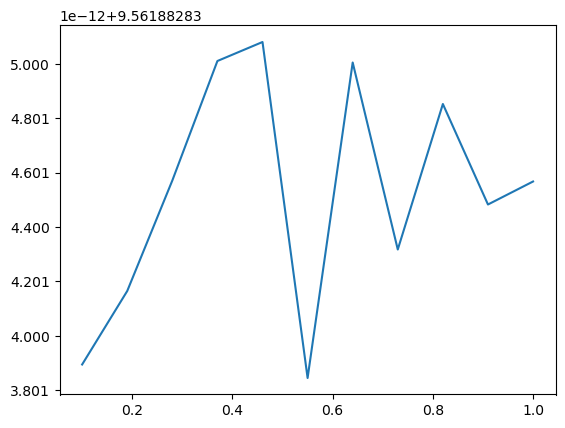

In [ ]:
def integral_int_boundary(integration_boundary, temperature, n):
    xs = np.linspace(-10 * temperature, 10 * temperature, 500)

    int_exact = integrate.trapezoid(derivative_FD(xs, temperature), xs)
    x, weights = np.polynomial.legendre.leggauss(n)
    int_prox = np.sum(
        derivative_FD(x * integration_boundary, temperature)
        * weights
        * integration_boundary
    )
    return int_exact - int_prox


optimize.root(integral_int_boundary, 4, args=(T, 21)).x[0]


Ts = np.linspace(0.1, 1, 11)

ints = np.linspace(1, 10, 21)

for T in Ts:
    plt.plot(
        ints,
        [np.abs(integral_int_boundary(int_i, T, 11)) for int_i in ints],
        "-o",
        label=T,
    )

plt.yscale("log")

opts = [optimize.root(integral_int_boundary, 4, args=(T, 21)).x[0] for T in Ts]

plt.show()
plt.plot(Ts, opts / Ts)

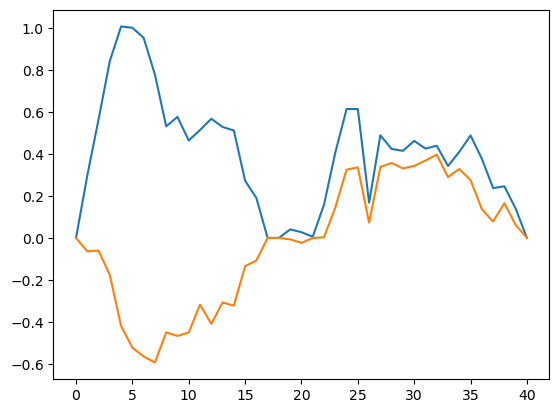

In [205]:
plt.plot(gs)
plt.plot(g_spin)

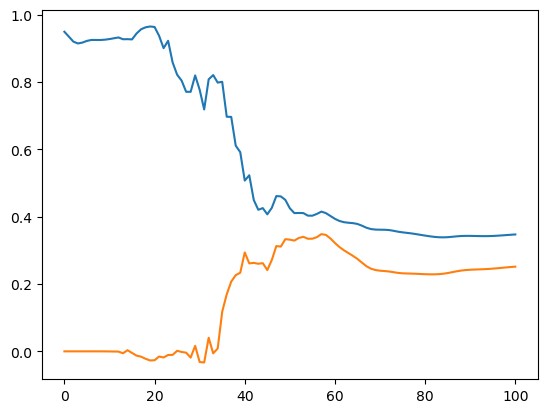

In [202]:
plt.plot(gs)
plt.plot(g_spin)

In [45]:
for x in [spectrals, spin_spectrals, fermi_energies, g_spin, Js, doss]:
    x = np.array(x)
g_spin = np.array(g_spin)

idx_Js = np.array([3, 4], dtype=int)


plt.plot(Js, g_spin, "r", label="spin cond")
plt.plot(Js, gs, "b", label="cond")
plt.plot(Js[idx_Js], g_spin[idx_Js], "ro")

# plt.plot(Js,fermi_energies)
plt.plot(Js, array_magnetization[idx_n].mean(axis=-1), "k", label="magnetization")
plt.plot(Js[idx_Js], array_magnetization[idx_n, idx_Js].mean(axis=-1), "ko")
plt.plot(Js, doss, color="gray", label="DOS")

plt.legend()


fig, axs = plt.subplots(2, len(idx_Js))

for j, idx_J in enumerate(idx_Js):

    axs[0, j].set_title("spectral")
    axs[0, j].imshow(
        np.abs(spectrals[idx_J]),
        cmap="magma",
        origin="lower",
    )
    axs[1, j].set_title("spin spectral")
    axs[1, j].imshow(
        spin_spectrals[idx_J],
        cmap="bwr",
        origin="lower",
        vmin=-0.2,
        vmax=+0.2,
    )
plt.tight_layout()

NameError: name 'spectrals' is not defined

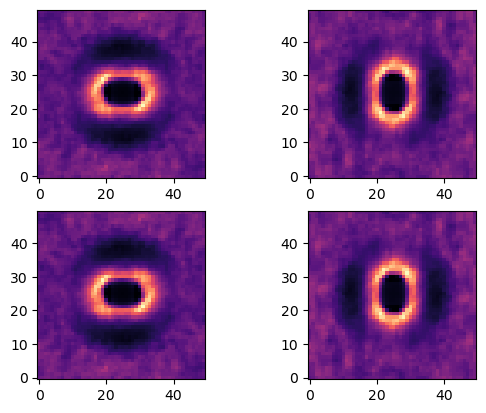

In [11]:
j = 0
idx_n = 6

data_entry = d["data"][idx_n, j]

hamiltonian = alt_hamiltonian(
    lattice,
    data_entry["hparam"]["t1"],
    data_entry["hparam"]["t2"],
    data_entry["hparam"]["J"] * 0,
    data_entry["hparam"]["J"] * 0,
    data_entry["hparam"]["m"] * 0,
    data_entry["hparam"]["n"],
    theta_offset=0,
)

# evaluating the Fermi energy
energies, states = la.eigh(hamiltonian)
fermi_energy = energies[
    int(data_entry["hparam"]["filling"] * len(energies))
]  # better algorithm to get Fermi energy


fig, axs = plt.subplots(2, 2)

axs[0, 0].imshow(
    spectral_function(
        lattice,
        energies,
        states,
        fermi_energy,
        local_operator=np.array([1, 0, 0, 0]),
        eta=1e-1,
        n_k=50,
    ),
    cmap="magma",
    origin="lower",
)
axs[0, 1].imshow(
    spectral_function(
        lattice,
        energies,
        states,
        fermi_energy,
        local_operator=np.array([0, 1, 0, 0]),
        eta=1e-1,
        n_k=50,
    ),
    cmap="magma",
    origin="lower",
)
axs[1, 0].imshow(
    spectral_function(
        lattice,
        energies,
        states,
        fermi_energy,
        local_operator=np.array([0, 0, 1, 0]),
        eta=1e-1,
        n_k=50,
    ),
    cmap="magma",
    origin="lower",
)
axs[1, 1].imshow(
    spectral_function(
        lattice,
        energies,
        states,
        fermi_energy,
        local_operator=np.array([0, 0, 0, 1]),
        eta=1e-1,
        n_k=50,
    ),
    cmap="magma",
    origin="lower",
)

1.5283519828430514


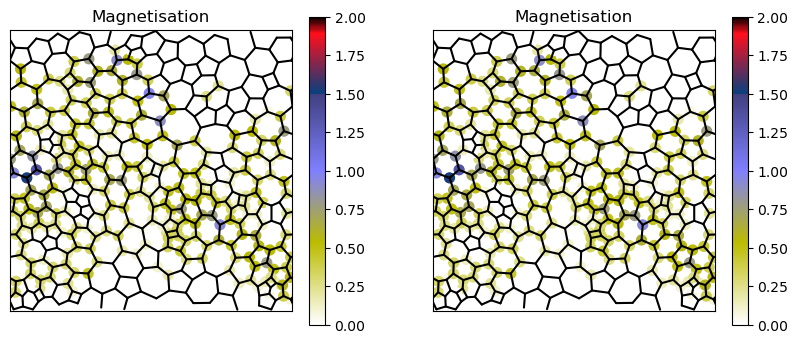

In [130]:
from koala import plotting as pl

idx_Js = np.array([16, 17], dtype=int)

dm = (
    100
    * (array_magnetization[idx_n, idx_Js[1]] - array_magnetization[idx_n, idx_Js[0]])
    / 2
)
print(dm.max())


fig, axs = plt.subplots(1, len(idx_Js), figsize=(len(idx_Js) * 5, 4))
for idx_J, ax in zip(idx_Js, axs):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=dm,  # array_magnetization[idx_n,idx_J],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )
    plt.colorbar(im, ax=ax)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Magnetisation")